# $(SASA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [2]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model, Triplet_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [3]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1022,4,42,"(0.0783299669233051, 0.1772545769968534)","(0.035, 0.427, 0.008, -1.504)",1,1.0,"(0.044, 0.645, -0.022, -2.309)",0.0,1.0,"(0.057, 0.427, -0.068, -1.515)"
1894,3,75,"(0.1183847760177763, 0.1905328618963407)","(-0.044, -0.689, 0.065, 2.408)",0,1.0,"(-0.058, -0.908, 0.113, 3.238)",0.0,1.0,"(-0.076, -1.127, 0.178, 4.101)"
2201,5,86,"(0.146849773871812, 0.9074407435603008)","(-0.022, -0.601, 0.037, 0.504)",0,1.0,"(-0.034, -0.791, 0.048, 0.678)",1.0,1.0,"(-0.05, -0.602, 0.061, 0.52)"
2193,15,85,"(0.2714262518980411, 0.6857384251475167)","(-0.151, -0.974, 0.138, 1.374)",1,1.0,"(-0.171, -0.783, 0.166, 1.169)",1.0,1.0,"(-0.186, -0.592, 0.189, 0.973)"
956,41,38,"(0.4545373771214862, 0.5810082803318615)","(0.197, 1.729, -0.135, -2.599)",1,1.0,"(0.231, 1.928, -0.187, -2.981)",1.0,1.0,"(0.27, 2.126, -0.247, -3.374)"
...,...,...,...,...,...,...,...,...,...,...
1898,2,76,"(0.0250474928798763, 0.8242933987226606)","(0.036, 0.427, 0.016, -0.308)",0,1.0,"(0.045, 0.238, 0.01, -0.137)",0.0,1.0,"(0.05, 0.048, 0.007, 0.033)"
663,51,23,"(0.2125978932043111, 0.6111562190979459)","(-0.293, -1.274, -0.161, 0.3)",0,1.0,"(-0.319, -1.465, -0.155, 0.511)",0.0,1.0,"(-0.348, -1.657, -0.145, 0.725)"
706,16,24,"(0.381115827959413, 0.5947037963670837)","(-0.044, -0.019, 0.064, 0.216)",0,1.0,"(-0.045, -0.216, 0.068, 0.546)",0.0,1.0,"(-0.049, -0.413, 0.079, 0.877)"
1086,27,44,"(0.1523965748487631, 0.5191136587315984)","(-0.088, -1.009, 0.107, 1.724)",1,1.0,"(-0.108, -0.815, 0.142, 1.466)",0.0,1.0,"(-0.124, -1.012, 0.171, 1.8)"


In [4]:
model = Model(transition_criterion_clss=Triplet_Loss)

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000, margin=.5)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,triplet,mse_s,transition,reward
0,0,1.009951,"[0.019536247476935387, 0.5180955529212952, 0.0...",2.458467,1.205479
1,1,1.009954,"[0.019363386556506157, 0.5150126814842224, 0.0...",2.444819,1.200960
2,2,1.009958,"[0.019207710400223732, 0.5119308829307556, 0.0...",2.431355,1.196562
3,3,1.009963,"[0.019069161266088486, 0.508868932723999, 0.06...",2.418071,1.192415
4,4,1.009969,"[0.018945353105664253, 0.505818784236908, 0.05...",2.404954,1.188677


In [5]:
data.training_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__
1022,4,42,"(0.0783299669233051, 0.1772545769968534)","(0.035, 0.427, 0.008, -1.504)",1,1.0,"(0.044, 0.645, -0.022, -2.309)",0.0,1.0,"(0.057, 0.427, -0.068, -1.515)"
1894,3,75,"(0.1183847760177763, 0.1905328618963407)","(-0.044, -0.689, 0.065, 2.408)",0,1.0,"(-0.058, -0.908, 0.113, 3.238)",0.0,1.0,"(-0.076, -1.127, 0.178, 4.101)"
2201,5,86,"(0.146849773871812, 0.9074407435603008)","(-0.022, -0.601, 0.037, 0.504)",0,1.0,"(-0.034, -0.791, 0.048, 0.678)",1.0,1.0,"(-0.05, -0.602, 0.061, 0.52)"
2193,15,85,"(0.2714262518980411, 0.6857384251475167)","(-0.151, -0.974, 0.138, 1.374)",1,1.0,"(-0.171, -0.783, 0.166, 1.169)",1.0,1.0,"(-0.186, -0.592, 0.189, 0.973)"
956,41,38,"(0.4545373771214862, 0.5810082803318615)","(0.197, 1.729, -0.135, -2.599)",1,1.0,"(0.231, 1.928, -0.187, -2.981)",1.0,1.0,"(0.27, 2.126, -0.247, -3.374)"


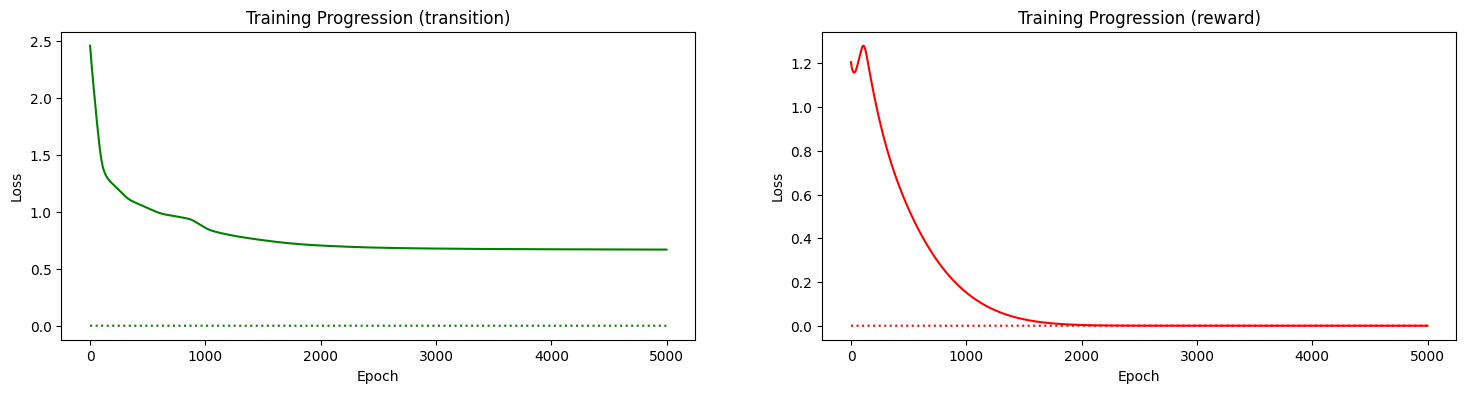

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

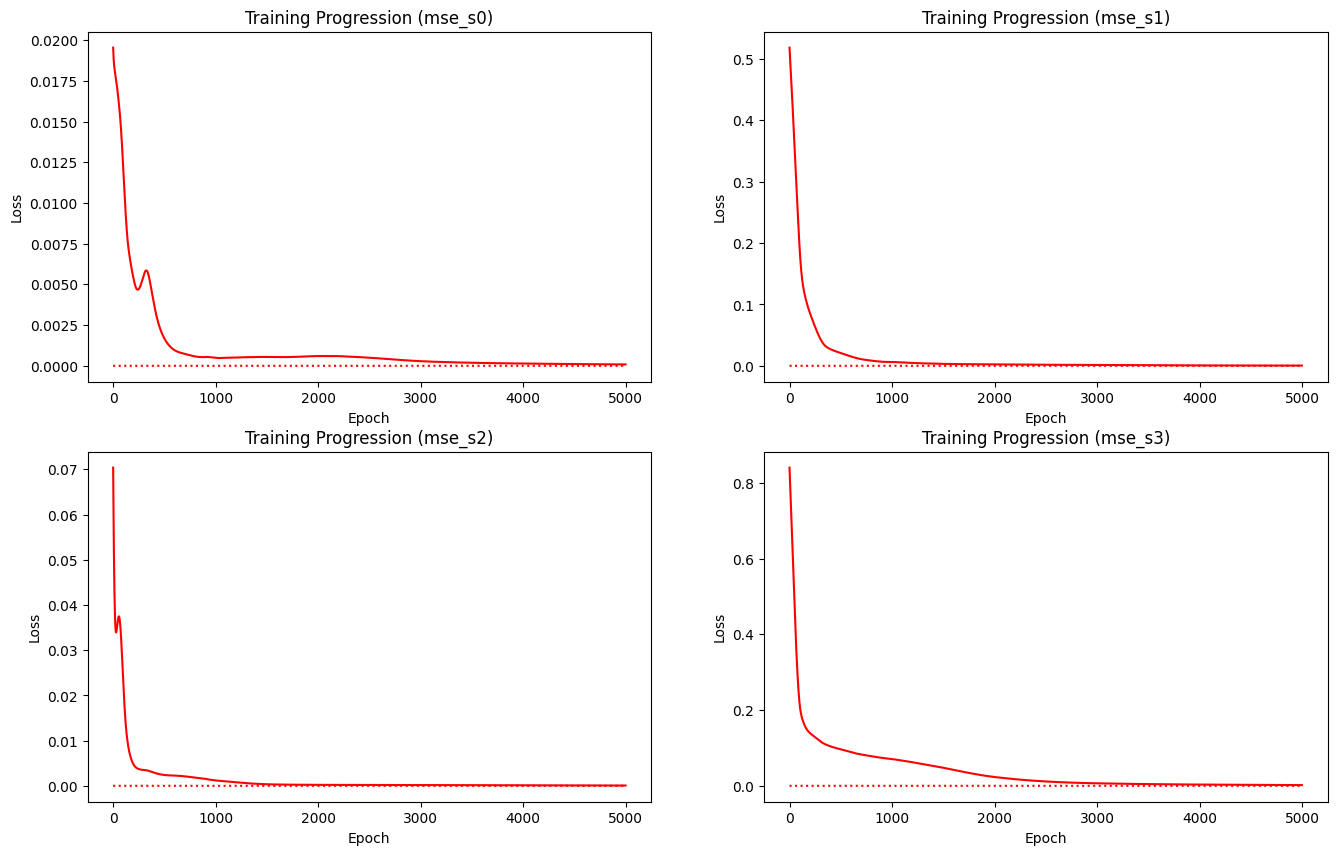

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    # 'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    # 'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

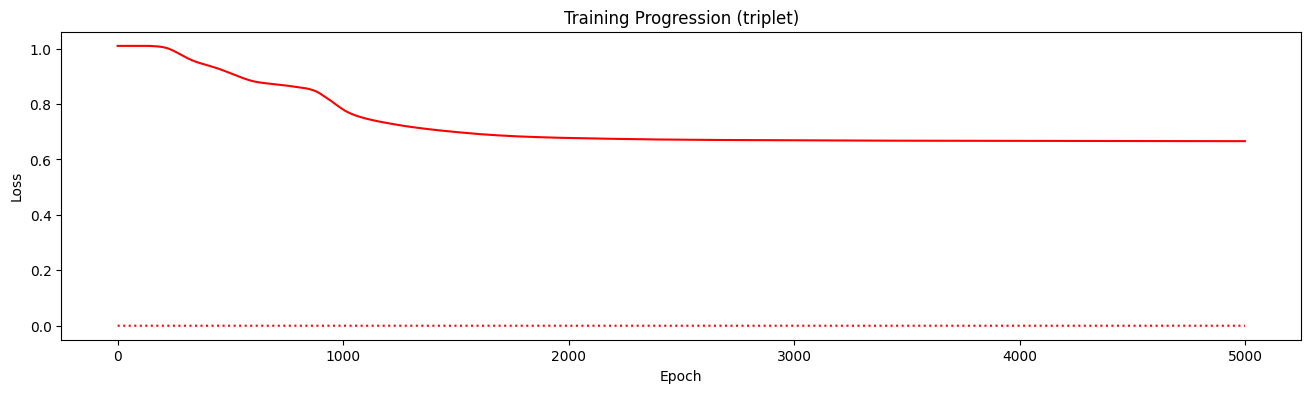

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(16, 4))

data.plot_training_loss(axs, df['triplet'], 'r')

plt.show()

## Params

In [9]:
import pandas as pd

training_params = pd.DataFrame(y.numpy(), columns=model.targets_lables)

expansions = {
    'p': ['p0', 'p1']
}
df_trainning = get_data_expanded(data.training_data.loc[(data.training_data.epoch==499)], expansions)

df_trainning_p = pd.DataFrame([], columns=['epoch', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1', 'p0', 'p1'])
for epoch in df_trainning.epoch.unique():
    copy = df_trainning[df_trainning.epoch == epoch].copy()[['epoch', 'p0', 'p1']].reset_index(drop=True)
    copy[['sample', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']] = training_params.copy()[['positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']].reset_index()
    df_trainning_p = pd.concat([df_trainning_p, copy])

df_trainning_p.head()

/tmp/ipykernel_3576/580248604.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_trainning_p = pd.concat([df_trainning_p, copy])


,epoch,positive_p0,positive_p1,negative_p0,negative_p1,p0,p1,sample
0,499,0.078330,0.177255,0.106400,0.317396,1.020536,-0.823285,0.0
1,499,0.118385,0.190533,0.143303,1.807597,-0.898107,-1.438049,1.0
2,499,0.146850,0.907441,0.341410,0.515999,-0.302161,-0.414523,2.0
3,499,0.271426,0.685738,0.021121,0.380193,-0.415380,-0.683040,3.0
4,499,0.454537,0.581008,0.042429,0.420015,0.792190,1.088578,4.0


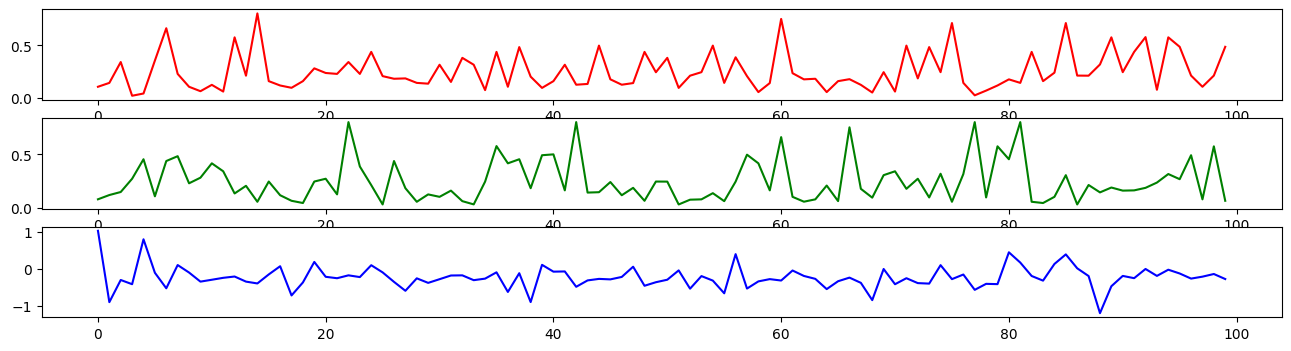

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(16, 4))

axs[0].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['negative_p0'], color='r', label='negative')
axs[1].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['positive_p0'], color='g', label='positve')
axs[2].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['p0'], color='b', label='estimative')

plt.show()

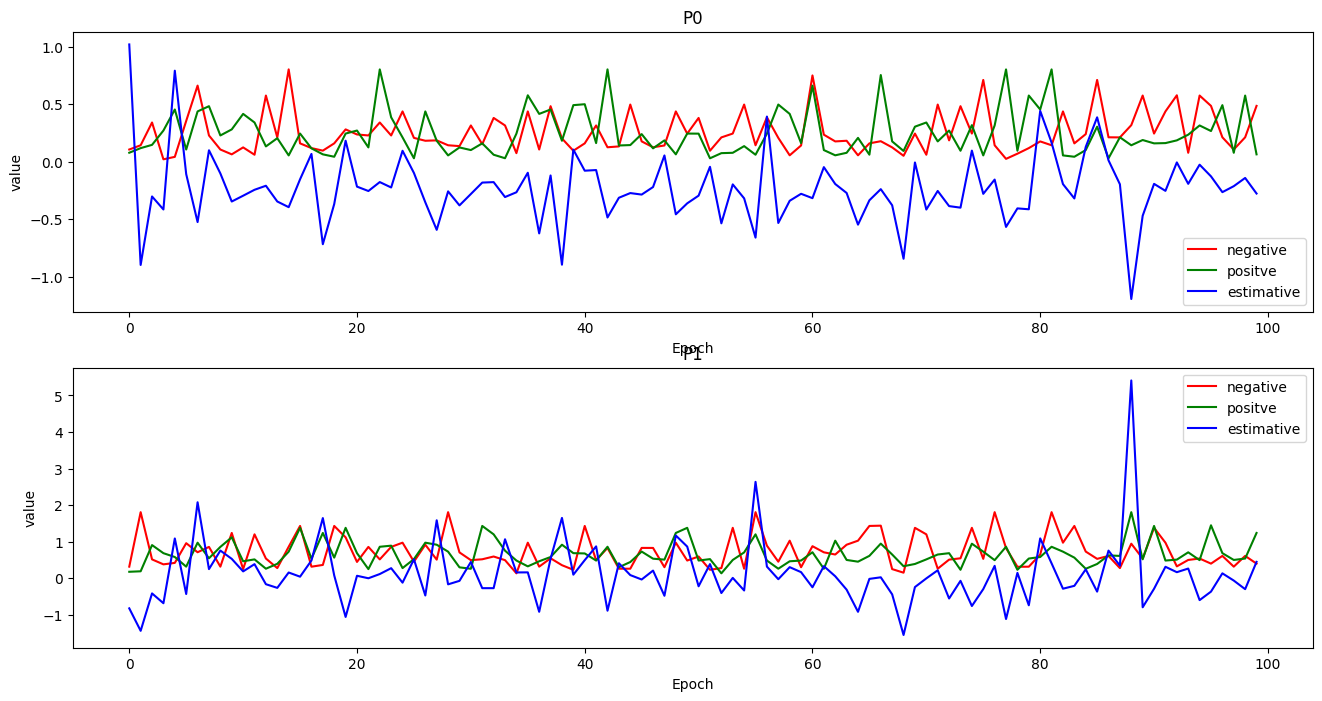

In [11]:
fig, axs = plt.subplots(2,1, figsize=(16, 8))

# df = df_trainning_p.groupby('epoch').mean()
# df = df_trainning_p.groupby('sample').mean()
df = df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]

axs[0].plot(df['negative_p0'], color='r', label='negative')
axs[0].plot(df['positive_p0'], color='g', label='positve')
axs[0].plot(df['p0'], color='b', label='estimative')

axs[0].set_ylabel('value')
axs[0].set_xlabel('Epoch')
axs[0].set_title(f'P0')
axs[0].legend()

axs[1].plot(df['negative_p1'], color='r', label='negative')
axs[1].plot(df['positive_p1'], color='g', label='positve')
axs[1].plot(df['p1'], color='b', label='estimative')

axs[1].set_ylabel('value')
axs[1].set_xlabel('Epoch')
axs[1].set_title(f'P1')
axs[1].legend()

plt.show()

## Best and worst episodes

In [12]:
data.evaluate_model(model, path='training_data.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
0,0,0,"(0.0730412080386606, 0.3656961190344961)","(0.011, 0.034, 0.014, 0.009)",0,1.0,"(0.012, -0.165, 0.014, 0.407)",0.0,1.0,"(0.009, -0.365, 0.023, 0.806)",...,0.002,0.003,0.020,0.0,0.015748,0.007326,0.027027,0.021482,0.027,0.025397
1,1,0,"(0.0730412080386606, 0.3656961190344961)","(0.012, -0.165, 0.014, 0.407)",0,1.0,"(0.009, -0.365, 0.023, 0.806)",0.0,1.0,"(0.001, -0.565, 0.039, 1.207)",...,0.008,0.005,0.031,0.0,0.023622,0.029304,0.045045,0.033298,0.047,0.046561
2,2,0,"(0.0730412080386606, 0.3656961190344961)","(0.009, -0.365, 0.023, 0.806)",0,1.0,"(0.001, -0.565, 0.039, 1.207)",0.0,1.0,"(-0.01, -0.766, 0.063, 1.616)",...,0.011,0.005,0.025,0.0,0.015748,0.040293,0.045045,0.026853,0.043,0.042328
3,3,0,"(0.0730412080386606, 0.3656961190344961)","(0.001, -0.565, 0.039, 1.207)",0,1.0,"(-0.01, -0.766, 0.063, 1.616)",1.0,1.0,"(-0.025, -0.567, 0.095, 1.25)",...,0.006,0.002,0.014,0.0,0.007874,0.021978,0.018018,0.015038,0.023,0.021164
4,4,0,"(0.0730412080386606, 0.3656961190344961)","(-0.01, -0.766, 0.063, 1.616)",1,1.0,"(-0.025, -0.567, 0.095, 1.25)",1.0,1.0,"(-0.036, -0.369, 0.12, 0.9)",...,0.002,0.001,0.020,0.0,0.023622,0.007326,0.009009,0.021482,0.026,0.024339


In [13]:
rmse = results[['episode', 'rse_s0', 'rse_s1', 'rse_s2', 'rse_s3']].groupby('episode').mean().reset_index()
rmse['rmse'] = rmse.rse_s0 + rmse.rse_s1 + rmse.rse_s2 + rmse.rse_s3
rmse_sorted = rmse.sort_values(by='rmse')
epis = rmse.shape[0]

best_episodes = rmse_sorted.head(3).episode.values
worst_episodes = rmse_sorted.tail(3).episode.values
print(f'{best_episodes=}', f'{worst_episodes=}')

best_episodes=array([84, 27, 74]) worst_episodes=array([20, 17, 32])


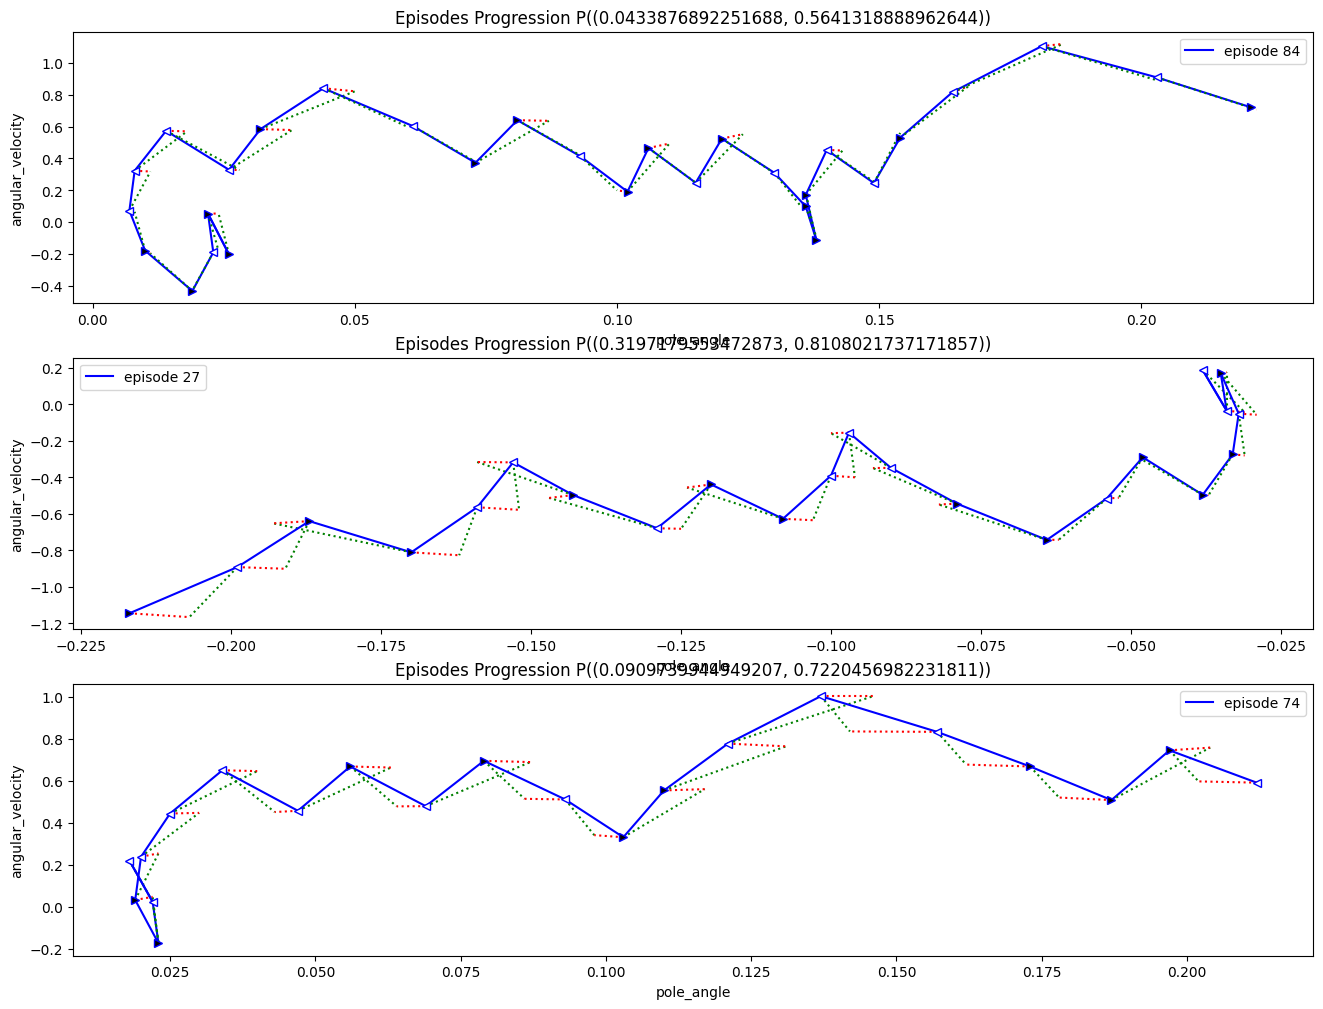

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(best_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

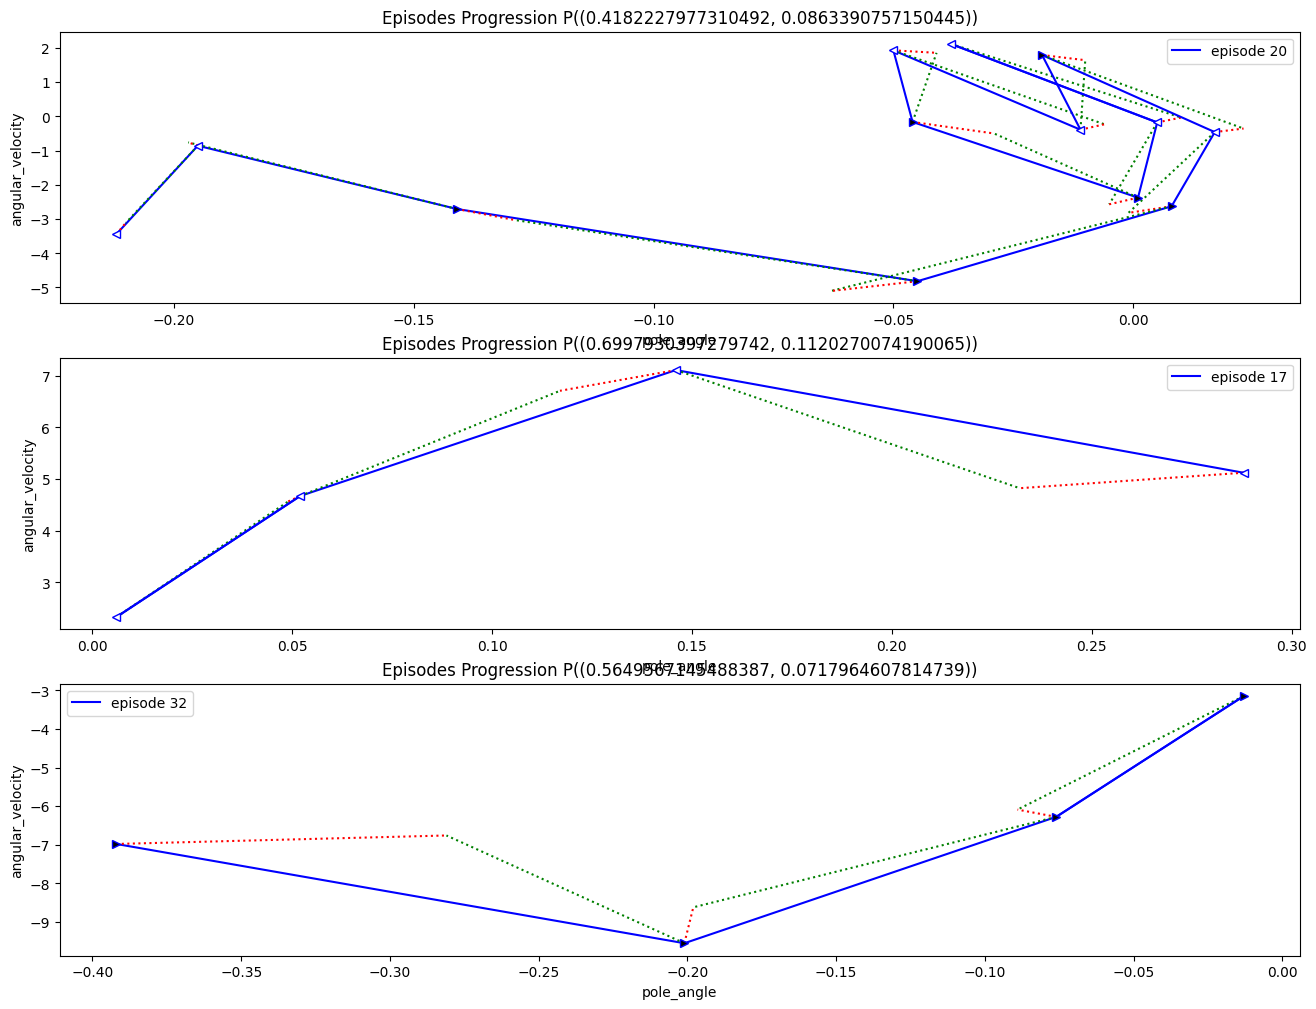

In [15]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(worst_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

## Kmeans

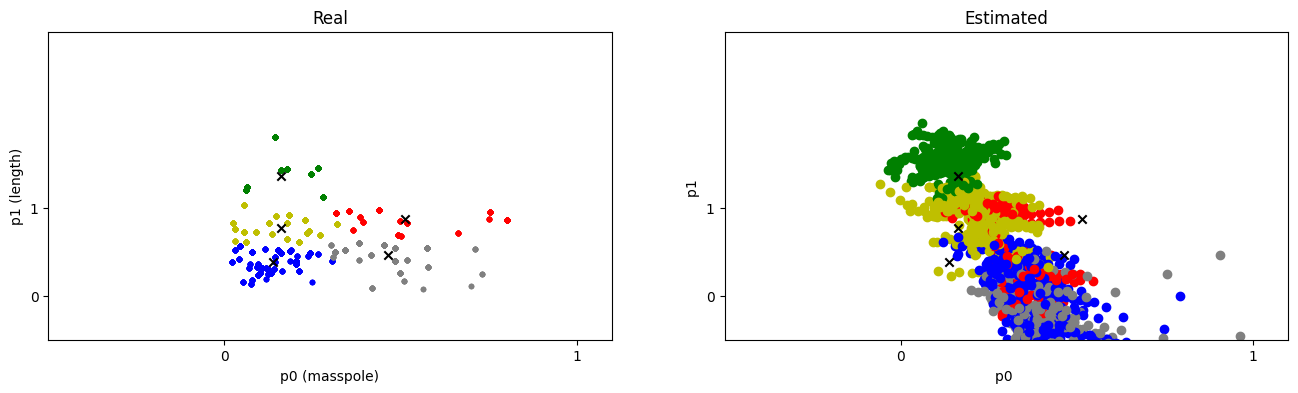

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
data.plot_clusters(axs, results)
plt.show()

# Evaluation

In [17]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
0,0,0,"(0.5280280669895349, 0.1691488904272192)","(-0.018, -0.046, 0.013, -0.019)",0,1.0,"(-0.019, -0.285, 0.013, 1.258)",0.0,1.0,"(-0.025, -0.525, 0.038, 2.534)",...,0.053,0.006,0.258,0.0,0.158537,0.209486,0.077922,0.579775,0.330,0.493192
1,1,0,"(0.5280280669895349, 0.1691488904272192)","(-0.019, -0.285, 0.013, 1.258)",0,1.0,"(-0.025, -0.525, 0.038, 2.534)",1.0,1.0,"(-0.035, -0.288, 0.088, 1.326)",...,0.011,0.009,0.041,0.0,0.134146,0.043478,0.116883,0.092135,0.072,0.102874
2,2,0,"(0.5280280669895349, 0.1691488904272192)","(-0.025, -0.525, 0.038, 2.534)",1,1.0,"(-0.035, -0.288, 0.088, 1.326)",0.0,1.0,"(-0.041, -0.532, 0.115, 2.694)",...,0.054,0.004,0.164,0.0,0.170732,0.213439,0.051948,0.368539,0.236,0.350983
3,3,0,"(0.5280280669895349, 0.1691488904272192)","(-0.035, -0.288, 0.088, 1.326)",0,1.0,"(-0.041, -0.532, 0.115, 2.694)",1.0,1.0,"(-0.052, -0.3, 0.169, 1.601)",...,0.004,0.006,0.054,0.0,0.292683,0.015810,0.077922,0.121348,0.088,0.127080
4,4,0,"(0.5280280669895349, 0.1691488904272192)","(-0.041, -0.532, 0.115, 2.694)",1,1.0,"(-0.052, -0.3, 0.169, 1.601)",0.0,1.0,"(-0.058, -0.546, 0.201, 3.045)",...,0.055,0.002,0.021,0.0,0.182927,0.217391,0.025974,0.047191,0.093,0.134644


In [ ]:
results[['rse_s0','rse_s1','rse_s2','rse_s3','rse_r','rse_s0_normalized','rse_s1_normalized','rse_s2_normalized','rse_s3_normalized', 'rse']].describe()

,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
count,2127.000000,2127.000000,2127.000000,2127.000000,2127.0,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000
mean,0.004560,0.010354,0.005076,0.026933,0.0,0.055615,0.040927,0.065918,0.060524,0.046924,0.064938
std,0.005282,0.014004,0.006131,0.038222,0.0,0.064412,0.055353,0.079625,0.085892,0.050420,0.076278
min,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.004000,0.000000
25%,0.001000,0.004000,0.002000,0.008000,0.0,0.012195,0.015810,0.025974,0.017978,0.022000,0.027231
50%,0.003000,0.007000,0.004000,0.017000,0.0,0.036585,0.027668,0.051948,0.038202,0.033000,0.043873
75%,0.006000,0.012000,0.006000,0.031000,0.0,0.073171,0.047431,0.077922,0.069663,0.052000,0.072617
max,0.082000,0.253000,0.077000,0.445000,0.0,1.000000,1.000000,1.000000,1.000000,0.665000,1.000000


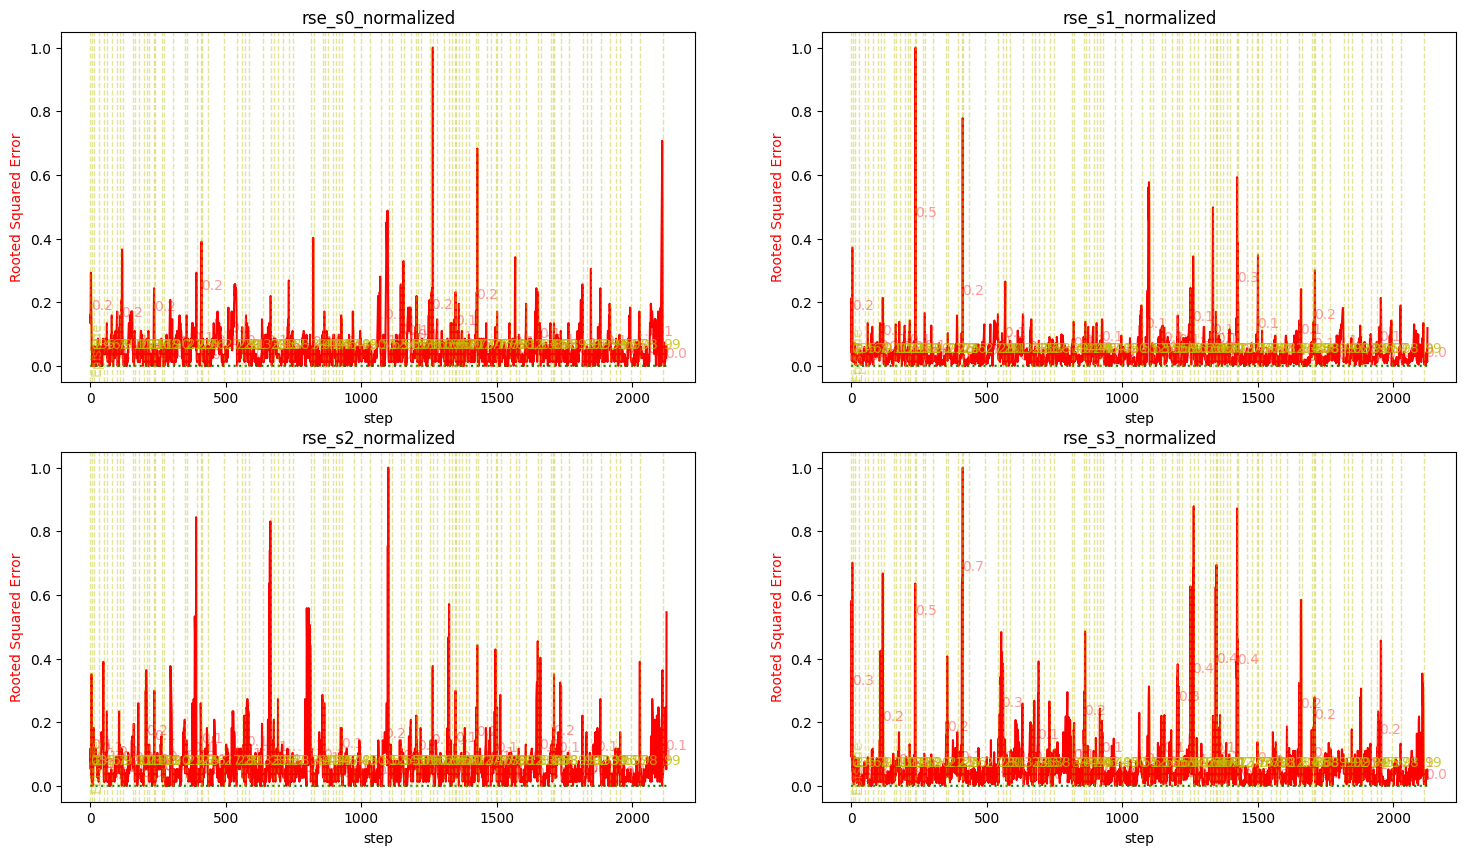

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0_normalized')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1_normalized')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2_normalized')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3_normalized')

plt.show()

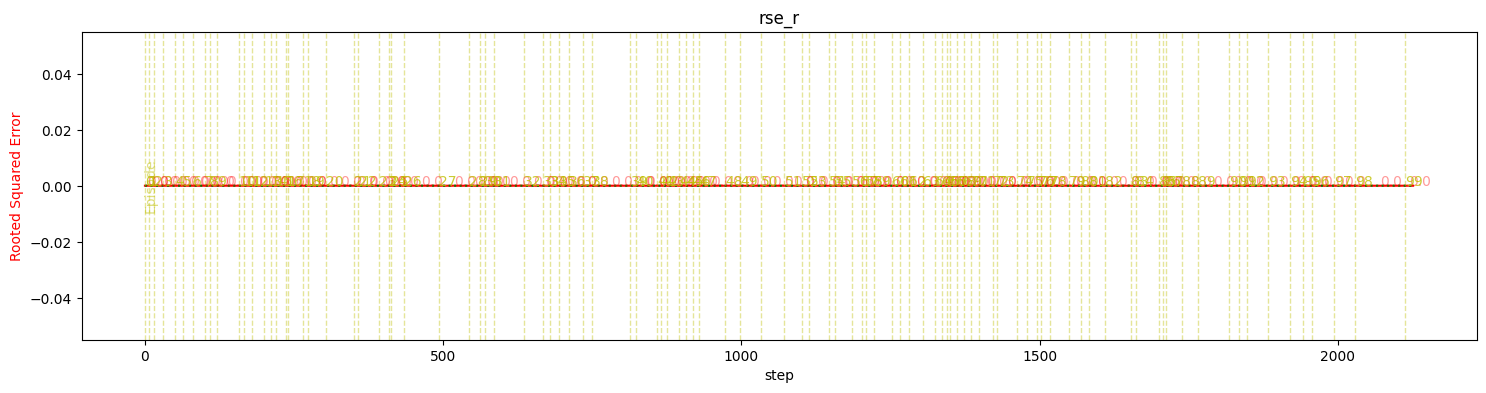

In [20]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

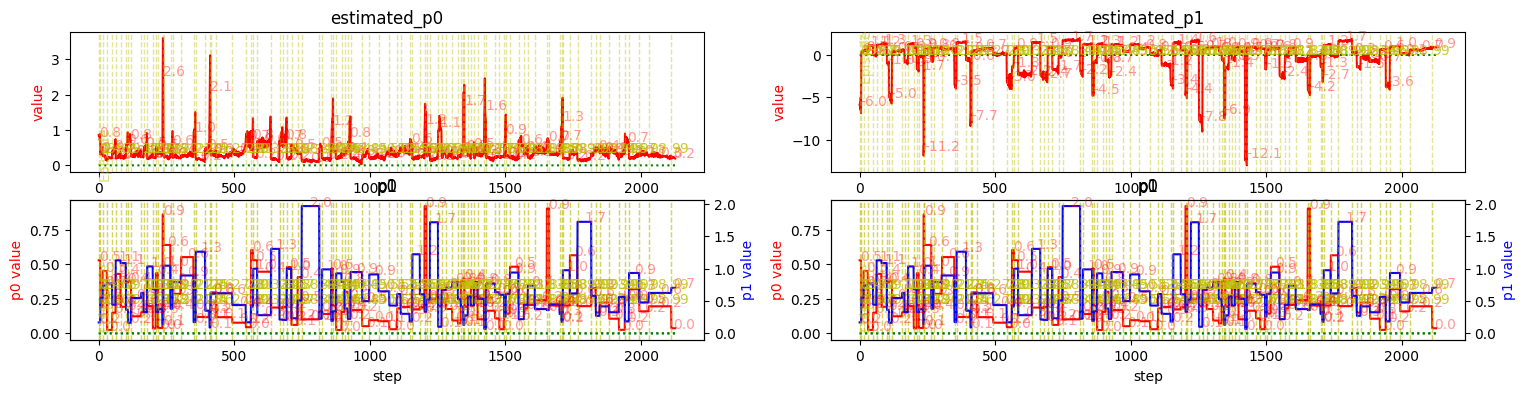

In [ ]:
n = 10

df = results[['episode', 'estimated_p0', 'estimated_p1', 'p0', 'p1']].groupby("episode").mean().reset_index()
df['dist_p0'] = np.sqrt(np.pow(df['estimated_p0']-df['p0'], 2))
df['dist_p1'] = np.sqrt(np.pow(df['estimated_p1']-df['p1'], 2))
df['dist'] = df['dist_p0'] + df['dist_p1']
worst = df.loc[df.rank(ascending=False)['dist']<=n].episode
df = results[results['episode'].isin(worst)].reset_index(drop=True)

fig, axs = plt.subplots(2, 2, figsize=(18,4))
data.plot_value_through_episodes(axs[0][0], df, 'estimated_p0', y_label='value')
data.plot_value_through_episodes(axs[0][1], df, 'estimated_p1', y_label='value')

data.plot_value_through_episodes(axs[1][0], df, 'p0', y_label='p0 value')
data.plot_value_through_episodes(axs[1][0].twinx(), df, 'p1', y_label='p1 value', color='b')

data.plot_value_through_episodes(axs[1][1], df, 'p0', y_label='p0 value')
data.plot_value_through_episodes(axs[1][1].twinx(), df, 'p1', y_label='p1 value', color='b')

plt.show()

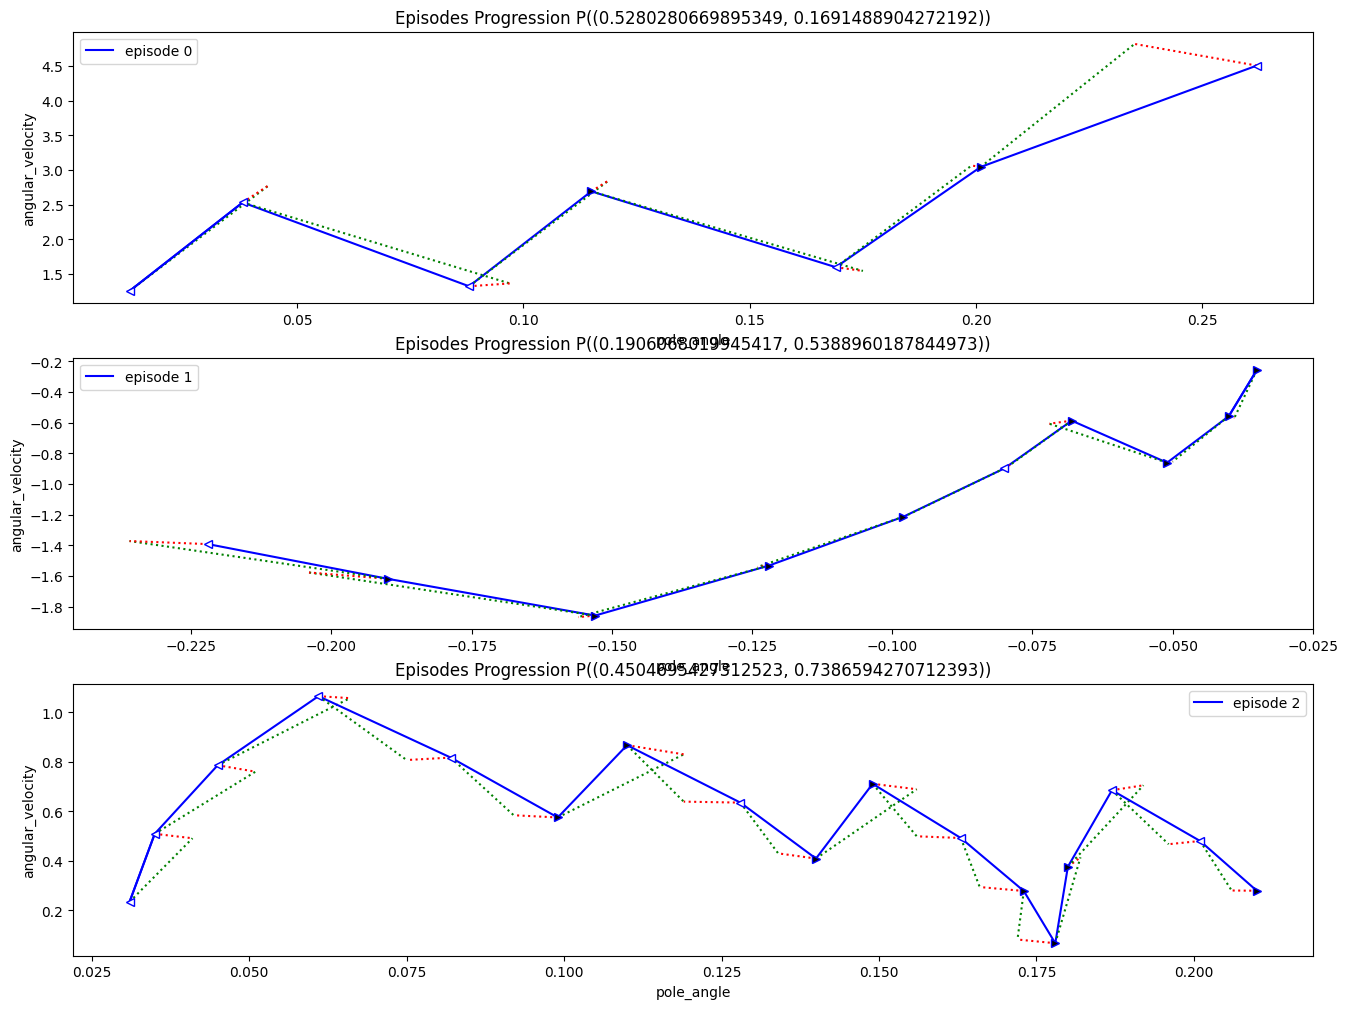

In [22]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()

## Cluster

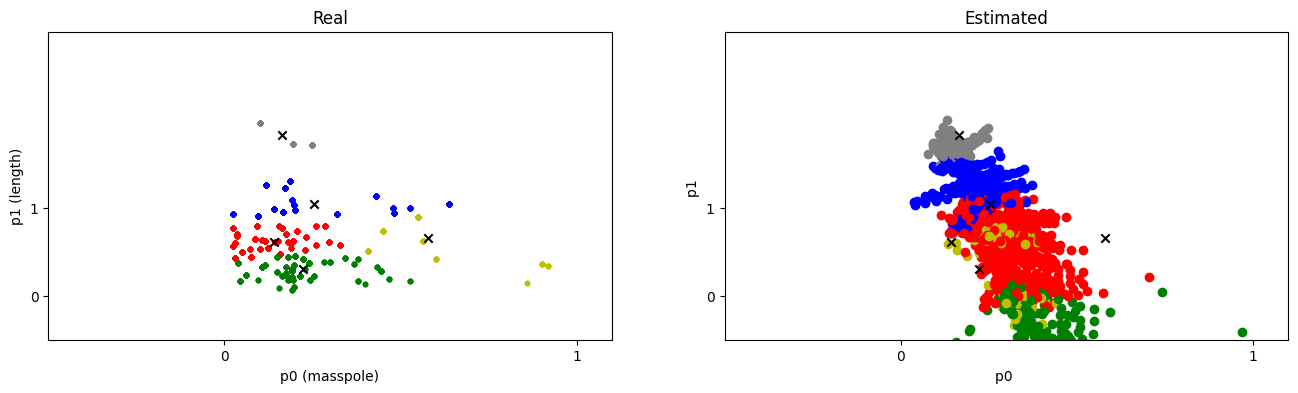

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
data.plot_clusters(axs, results)
plt.show()

In [ ]:
# import pickle

# exp = {
#     "data": data,
#     "model": model 
# }

# nome_do_arquivo = 'triplet.pkl'
# with open(nome_do_arquivo, 'wb') as arquivo:
#     pickle.dump(exp, arquivo)